## Défi quotidien : Analyse de texte de livres en utilisant un nuage de mots

### Configuration : Installer et importer les bibliothèques

In [19]:
# Installer les bibliothèques nécessaires
!pip install nltk spacy wordcloud requests
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 51.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [20]:
# Importer les bibliothèques
import requests
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import spacy
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

# Télécharger les données NLTK (si ce n'est pas déjà fait)
nltk.download('punkt')
nltk.download('punkt_tab') # Ajouter cette ligne pour télécharger la ressource manquante
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') # Cette ligne a été ajoutée pour le téléchargement du tagger POS
nltk.download('maxent_ne_chunker')
nltk.download('words')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

### Prétraitement du texte

#### 1. En utilisant `requests` pour accéder au contenu en ligne, créez une fonction `load_texts()`. Cette fonction doit recevoir une liste d'URLs, les charger, nettoyer les non-mots à l'aide d'expressions régulières et ajouter le texte nettoyé au corpus qui sera renvoyé.

In [21]:
def load_texts(urls):
    corpus = []
    for url in urls:
        try:
            response = requests.get(url)
            response.raise_for_status()  # Lever une exception pour les erreurs HTTP
            text = response.text
            # Nettoyer les non-mots (ne garder que les lettres, les chiffres et la ponctuation de base)
            cleaned_text = re.sub(r'[^a-zA-Z0-9\s.,!?'-']', ' ', text)
            cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
            corpus.append(cleaned_text)
        except requests.exceptions.RequestException as e:
            print(f"Erreur de chargement {url}: {e}")
    return corpus

# URLs des livres
book_urls = [
    "https://www.gutenberg.org/files/11/11-0.txt", # Les Aventures d'Alice au Pays des Merveilles
    "https://www.gutenberg.org/files/12/12-0.txt", # De l'autre côté du miroir
    "https://www.gutenberg.org/files/830/830-0.txt"  # Un Conte Embrouillé
]

raw_texts = load_texts(book_urls)

# Attribuer des noms pour une référence plus facile
book_titles = [
    "Alice's Adventures in Wonderland",
    "Through the Looking-Glass",
    "A Tangled Tale"
]

SyntaxError: unexpected character after line continuation character (1648761018.py, line 9)

#### 2. Imprimez les 200 premiers caractères de chaque texte. Y a-t-il des parties du texte qui ne sont pas pertinentes pour l'analyse ? Si oui, vous devez les supprimer.

indice : Vous pouvez utiliser le découpage pour commencer et arrêter le texte là où vous en avez besoin (en ignorant les crédits d'auteur au début et à la fin) en recherchant les phrases suivantes :

' START'
' END'

In [22]:
cleaned_corpus = []
for i, text in enumerate(raw_texts):
    print(f"\n--- {book_titles[i]} (200 premiers caractères) ---")
    print(text[:200])

    # Appliquer le découpage pour supprimer le texte générique
    # Trouver les marqueurs 'START' et 'END' pour le contenu
    start_marker = text.find('*** START')
    end_marker = text.find('*** END')

    if start_marker != -1 and end_marker != -1:
        # Ajuster le marqueur de début pour sauter la ligne 'START' elle-même
        start_index = text.find('\n\n', start_marker) + 2 # +2 pour sauter deux nouvelles lignes
        if start_index == 1: # Si une seule nouvelle ligne, ajuster
             start_index = text.find('\n', start_marker) + 1
        if start_index == -1: # Repli si des nouvelles lignes spécifiques ne sont pas trouvées
             start_index = start_marker + len('*** START OF THE PROJECT GUTENBERG EBOOK')

        cleaned_text = text[start_index:end_marker].strip()
    else:
        # Repli si les marqueurs ne sont pas trouvés, ou gérer différemment
        cleaned_text = text

    cleaned_corpus.append(cleaned_text)

print("\n--- 200 premiers caractères des textes nettoyés ---")
for i, text in enumerate(cleaned_corpus):
    print(f"\n--- {book_titles[i]} ---")
    print(text[:200])


--- Alice's Adventures in Wonderland (200 premiers caractères) ---
START OF THE PROJECT GUTENBERG EBOOK 11 Illustration Alice s Adventures in Wonderland by Lewis Carroll THE MILLENNIUM FULCRUM EDITION 3.0 Contents CHAPTER I. Down the Rabbit-Hole CHAPTER II. The Pool 

--- Through the Looking-Glass (200 premiers caractères) ---
START OF THE PROJECT GUTENBERG EBOOK 12 Illustration THROUGH THE LOOKING-GLASS And What Alice Found There By Lewis Carroll The Millennium Fulcrum Edition 1.7 DRAMATIS PERSON . As arranged before comme

--- A Tangled Tale (200 premiers caractères) ---
The Project Gutenberg EBook of The Argonautica, by Apollonius Rhodius This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no 

--- 200 premiers caractères des textes nettoyés ---

--- Alice's Adventures in Wonderland ---
START OF THE PROJECT GUTENBERG EBOOK 11 Illustration Alice s Adventures in Wonderland by Lewis Carroll THE MILLENNIUM FULCR

#### 3. Tokenisez le texte et imprimez les 150 premiers tokens de chaque livre

In [23]:
tokenized_texts = []
for i, text in enumerate(cleaned_corpus):
    # Convertir en minuscules avant de tokeniser pour la cohérence
    tokens = nltk.word_tokenize(text.lower())
    tokenized_texts.append(tokens)
    print(f"\n--- {book_titles[i]} (150 premiers tokens) ---")
    print(tokens[:150])


--- Alice's Adventures in Wonderland (150 premiers tokens) ---
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', '11', 'illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', '3.0', 'contents', 'chapter', 'i.', 'down', 'the', 'rabbit-hole', 'chapter', 'ii', '.', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', '.', 'a', 'caucus-race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', '.', 'the', 'rabbit', 'sends', 'in', 'a', 'little', 'bill', 'chapter', 'v.', 'advice', 'from', 'a', 'caterpillar', 'chapter', 'vi', '.', 'pig', 'and', 'pepper', 'chapter', 'vii', '.', 'a', 'mad', 'tea-party', 'chapter', 'viii', '.', 'the', 'queen', 's', 'croquet-ground', 'chapter', 'ix', '.', 'the', 'mock', 'turtle', 's', 'story', 'chapter', 'x.', 'the', 'lobster', 'quadrille', 'chapter', 'xi', '.', 'who', 'stole', 'the', 'tarts', '?', 'chapter', 'xii', '.', 'alice', 's', 'evidence', 'chapter', 'i.', 'down', 'the', 'rabbit-hole',

#### 4. Supprimez les mots vides en utilisant NLTK. Vérifiez qu'ils ont été supprimés en utilisant `count()` et en recherchant certains des mots vides comme : 'je', 'moi', 'mon', 'moi-même', 'nous', 'notre', 'nos', 'nous-mêmes', etc.

In [24]:
stop_words = set(stopwords.words('english'))
filtered_tokenized_texts = []

for i, tokens in enumerate(tokenized_texts):
    filtered_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    filtered_tokenized_texts.append(filtered_tokens)

    print(f"\n--- {book_titles[i]} (Après suppression des mots vides) ---")
    print(f"Total des tokens avant : {len(tokens)}")
    print(f"Total des tokens après : {len(filtered_tokens)}")

    # Vérifier la présence de mots vides spécifiques
    sample_stopwords = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves']
    for sw in sample_stopwords:
        count_before = tokens.count(sw)
        count_after = filtered_tokens.count(sw)
        print(f"'{sw}' compte avant : {count_before}, compte après : {count_after}")
    print(f"100 premiers tokens filtrés : {filtered_tokens[:100]}")


--- Alice's Adventures in Wonderland (Après suppression des mots vides) ---
Total des tokens avant : 31367
Total des tokens après : 12057
'i' compte avant : 544, compte après : 0
'me' compte avant : 68, compte après : 0
'my' compte avant : 58, compte après : 0
'myself' compte avant : 7, compte après : 0
'we' compte avant : 34, compte après : 0
'our' compte avant : 8, compte après : 0
'ours' compte avant : 1, compte après : 0
'ourselves' compte avant : 1, compte après : 0
100 premiers tokens filtrés : ['start', 'project', 'gutenberg', 'ebook', 'illustration', 'alice', 'adventures', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'sends', 'little', 'bill', 'chapter', 'advice', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'chapter', 'viii', 'queen', 'chapter', 'ix', 'mock', 'turtle', 'story', 'chapter', 'lobster', 'quadri

#### 5. En utilisant PorterStemmer(), imprimez les 50 premiers tokens racinisés

In [25]:
porter = PorterStemmer()
stemmed_texts = []

for i, tokens in enumerate(filtered_tokenized_texts):
    stemmed_tokens = [porter.stem(word) for word in tokens]
    stemmed_texts.append(stemmed_tokens)
    print(f"\n--- {book_titles[i]} (50 premiers tokens racinisés) ---")
    print(stemmed_tokens[:50])


--- Alice's Adventures in Wonderland (50 premiers tokens racinisés) ---
['start', 'project', 'gutenberg', 'ebook', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'chapter', 'viii', 'queen', 'chapter', 'ix', 'mock', 'turtl', 'stori', 'chapter', 'lobster', 'quadril']

--- Through the Looking-Glass (50 premiers tokens racinisés) ---
['start', 'project', 'gutenberg', 'ebook', 'illustr', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'dramati', 'person', 'arrang', 'commenc', 'game', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'queen', 'lili', 'queen', 'king

#### 6. En utilisant le modèle pré-entraîné de spaCy 'en_core_web_sm', chargez et imprimez les 50 premiers tokens lemmatisés. Indice : dans spaCy, le token lemmatisé peut être accédé comme attribut.

In [26]:
nlp = spacy.load('en_core_web_sm')
lemmatized_texts = []

for i, text in enumerate(cleaned_corpus):
    doc = nlp(text.lower()) # Traiter le texte brut nettoyé (en minuscules)
    # Filtrer les mots vides et les tokens non alphabétiques pendant la lemmatisation
    lemmas = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    lemmatized_texts.append(lemmas)
    print(f"\n--- {book_titles[i]} (50 premiers tokens lemmatisés) ---")
    print(lemmas[:50])


--- Alice's Adventures in Wonderland (50 premiers tokens lemmatisés) ---
['start', 'project', 'gutenberg', 'ebook', 'illustration', 'alice', 's', 'adventure', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'caucus', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'little', 'bill', 'chapter', 'advice', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'party', 'chapter', 'viii', 'queen', 's']

--- Through the Looking-Glass (50 premiers tokens lemmatisés) ---
['start', 'project', 'gutenberg', 'ebook', 'illustration', 'look', 'glass', 'alice', 'find', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'dramatis', 'person', 'arrange', 'commencement', 'game', 'white', 'red', 'piece', 'pawn', 'pawn', 'piece', 'tweedledee', 'daisy', 'daisy', 'humpty', 'dumpty', 'unicorn', 'haigha', 'messenger', 'carpenter', 'sheep', 'oyster', 'oyste

#### 7. Analysez la différence entre les tokens racinisés et lemmatisés. Qu'est-ce qui est différent et pourquoi ?

La principale différence entre la racinisation (stemming) et la lemmatisation réside dans leur approche pour réduire les mots à leur forme de base ou racine :

*   **Racinisation (par exemple, Porter Stemmer) :** C'est un processus plus rudimentaire qui tronque les terminaisons des mots pour arriver à une 'racine'. Il en résulte souvent des racines qui ne sont pas de véritables mots du dictionnaire. Par exemple, 'running', 'runs', 'ran' pourraient tous être racinisés en 'run'. L'objectif principal est de regrouper les mots ayant des significations similaires pour la recherche d'informations, même si la racine elle-même n'est pas grammaticalement correcte.

*   **Lemmatisation (par exemple, l'approche de spaCy) :** C'est un processus plus sophistiqué qui utilise un vocabulaire et une analyse morphologique des mots pour renvoyer la forme de base ou la forme du dictionnaire d'un mot, appelée 'lemme'. Le lemme est toujours un mot valide. Par exemple, 'running' serait lemmatisé en 'run', 'better' en 'good', et 'are' en 'be'. La lemmatisation prend en compte le contexte du mot et sa partie du discours pour s'assurer que la forme de base correcte est renvoyée.

**Pourquoi la différence ?**

La racinisation est généralement plus rapide et plus simple à implémenter, car elle est basée sur des règles. Cependant, elle peut produire des résultats moins précis et des non-mots. La lemmatisation, d'autre part, est plus intensive en calcul car elle nécessite des connaissances linguistiques (dictionnaires, étiquettes POS) mais fournit des formes de base plus précises et grammaticalement correctes. Pour les applications nécessitant une plus grande précision et des formes linguistiques appropriées (comme la compréhension du langage naturel ou la traduction automatique), la lemmatisation est généralement préférée. Pour une analyse de texte simple ou une recherche d'informations où la vitesse est essentielle, la racinisation peut être suffisante.

#### 8. En utilisant NLTK, identifiez les étiquettes POS de chaque texte.

In [27]:
pos_tagged_texts = []

for i, tokens in enumerate(filtered_tokenized_texts):
    # Étiqueter les tokens filtrés (après suppression des mots vides)
    tagged_tokens = nltk.pos_tag(tokens)
    pos_tagged_texts.append(tagged_tokens)
    print(f"\n--- {book_titles[i]} (50 premiers tokens étiquetés POS) ---")
    print(tagged_tokens[:50])

LookupError: 
**********************************************************************
  Resource [93maveraged_perceptron_tagger_eng[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('averaged_perceptron_tagger_eng')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtaggers/averaged_perceptron_tagger_eng/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


#### 9. En utilisant NLTK, identifiez toutes les entités de chaque texte

In [28]:
named_entities_texts = []

for i, tagged_tokens in enumerate(pos_tagged_texts):
    # Segmentation pour les entités nommées
    chunked_entities = nltk.ne_chunk(tagged_tokens)
    entities = []
    for subtree in chunked_entities.subtrees():
        if subtree.label() in ['PERSON', 'ORGANIZATION', 'GPE', 'LOCATION', 'FACILITY', 'GSP']:
            entity = " ".join([word for word, tag in subtree.leaves()])
            entities.append(entity)
    named_entities_texts.append(entities)
    print(f"\n--- {book_titles[i]} (20 premières entités nommées) ---")
    # Utiliser Counter pour afficher les entités les plus courantes
    entity_counts = Counter(entities)
    print(entity_counts.most_common(20))

### Analyse du texte

#### 1. En utilisant wordcloud et matplotlib, affichez un nuage de mots de chaque livre.

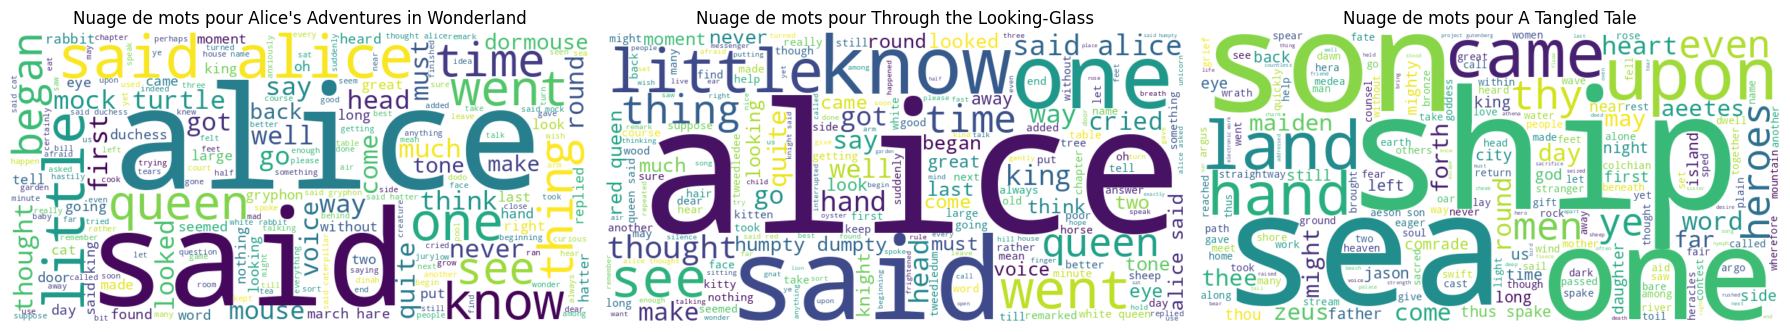

In [29]:
plt.figure(figsize=(18, 10))
for i, tokens in enumerate(filtered_tokenized_texts):
    text_for_wordcloud = " ".join(tokens)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_for_wordcloud)

    plt.subplot(1, 3, i + 1) # 1 ligne, 3 colonnes
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Nuage de mots pour {book_titles[i]}") # Ajouter un titre
    plt.axis('off')

plt.tight_layout()
plt.show()

#### 2. Utilisez la méthode BoW pour vérifier les cinq mots les plus fréquents dans tous les livres

indice : Quel sera le meilleur texte de l'étape de prétraitement ? (texte brut, racinisé, lemmatisé, etc.) ?

Pour vérifier les mots les plus fréquents et pour l'analyse Bag-of-Words (BoW) subséquente, le **texte lemmatisé (après suppression des mots vides et des tokens non alphabétiques)** est généralement le meilleur choix. Voici pourquoi :

*   **Texte brut :** Contient du bruit, de la ponctuation et des variations de capitalisation qui traiteraient "Alice", "alice", "Alice.", etc., comme des mots différents.
*   **Texte tokenisé :** Meilleur que le texte brut, mais contient toujours des mots vides et différentes inflexions du même mot (par exemple, "run", "running", "ran").
*   **Texte tokenisé filtré (mots vides supprimés) :** Supprime les mots courants et non informatifs, ce qui est bien, mais conserve toujours différentes inflexions.
*   **Texte racinisé :** Réduit les mots à une racine commune, ce qui est bon pour le regroupement, mais les racines peuvent ne pas être de véritables mots et peuvent être moins intuitives pour l'interprétation.
*   **Texte lemmatisé :** Réduit les mots à leur forme de base du dictionnaire (lemme), qui est un mot réel, tout en gérant les variations dues à la grammaire. Cela fournit un compte plus précis et significatif des concepts ou idées uniques dans le texte.

Par conséquent, nous utiliserons les `lemmatized_texts` pour l'analyse BoW.

In [30]:
from sklearn.feature_extraction.text import CountVectorizer

# Rejoindre les tokens lemmatisés en chaînes de caractères pour CountVectorizer
lemmatized_docs = [" ".join(tokens) for tokens in lemmatized_texts]

# Créer un CountVectorizer pour implémenter BoW
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(lemmatized_docs)

# Obtenir les noms des caractéristiques (mots)
feature_names = vectorizer.get_feature_names_out()

# Calculer les fréquences des mots dans tous les documents
word_counts = bow_matrix.sum(axis=0)
word_freq_df = pd.DataFrame({'word': feature_names, 'frequency': word_counts.tolist()[0]})

# Obtenir les cinq mots les plus fréquents
most_frequent_words = word_freq_df.sort_values(by='frequency', ascending=False).head(5)
print("Cinq mots les plus fréquents dans tous les livres (BoW) :")
print(most_frequent_words)

Cinq mots les plus fréquents dans tous les livres (BoW) :
       word  frequency
4569    say        991
162   alice        867
1045   come        448
2297     go        341
3078   like        317


#### 3. Imprimez le BoW et identifiez les nombres : Quel est le numéro du document ? Quel est l'indice et combien de fois le mot a-t-il été trouvé ?

In [31]:
print("\n--- Matrice Bag-of-Words (format creux) ---")
print(bow_matrix)

print("\nInterprétation de la matrice BoW :")
print("Chaque ligne correspond à un document (livre).")
print("Chaque colonne correspond à un mot unique dans le vocabulaire.")
print("Les valeurs dans la matrice représentent le compte de chaque mot dans chaque document.")

print("\nExemple de décomposition d'une entrée non nulle (par exemple, (numéro_document, index_mot) compte) :")
print("Le format (index_document, index_mot) compte indique :")
print("  - index_document : L'index basé sur zéro du document (0 pour Alice, 1 pour De l'autre côté du miroir, 2 pour Un Conte Embrouillé).")
print("  - index_mot : L'index basé sur zéro du mot dans le vocabulaire (peut être mappé au mot en utilisant `vectorizer.get_feature_names_out()[word_index]`).")
print("  - compte : Le nombre de fois que ce mot spécifique apparaît dans ce document spécifique.")

print("\n--- Exemple : Trouvons le compte de 'alice' dans 'Les Aventures d'Alice au Pays des Merveilles' ---")
alice_word_index = vectorizer.vocabulary_.get('alice')
if alice_word_index is not None:
    print(f"Index du mot 'alice' : {alice_word_index}")
    # Obtenir le compte de 'alice' dans le premier document (Alice's Adventures in Wonderland)
    count_alice_doc0 = bow_matrix[0, alice_word_index]
    print(f"Compte de 'alice' dans '{book_titles[0]}' : {count_alice_doc0}")
else:
    print("'alice' non trouvé dans le vocabulaire, vérifiez le prétraitement.")

print("\n--- Les 5 mots les plus fréquents et leurs comptes par livre ---")
for i, doc_title in enumerate(book_titles):
    print(f"\nLivre : {doc_title}")
    # Obtenir les comptes de mots pour le document actuel
    doc_word_counts = bow_matrix[i].toarray().flatten()
    doc_word_freq_df = pd.DataFrame({'word': feature_names, 'frequency': doc_word_counts})
    top_5_doc = doc_word_freq_df.sort_values(by='frequency', ascending=False).head(5)
    print(top_5_doc)


--- Matrice Bag-of-Words (format creux) ---
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8355 stored elements and shape (3, 6062)>
  Coords	Values
  (0, 5003)	3
  (0, 4113)	2
  (0, 2400)	2
  (0, 1682)	2
  (0, 2708)	1
  (0, 162)	399
  (0, 78)	7
  (0, 5967)	3
  (0, 3054)	1
  (0, 824)	1
  (0, 3341)	1
  (0, 2186)	1
  (0, 1694)	3
  (0, 1133)	2
  (0, 890)	24
  (0, 4221)	54
  (0, 2596)	6
  (0, 2704)	2
  (0, 4023)	12
  (0, 5229)	1
  (0, 2705)	2
  (0, 845)	4
  (0, 4222)	7
  (0, 3139)	38
  (0, 5207)	6
  :	:
  (2, 897)	1
  (2, 896)	1
  (2, 5617)	1
  (2, 3768)	1
  (2, 4891)	2
  (2, 1095)	1
  (2, 4892)	1
  (2, 4112)	1
  (2, 5657)	1
  (2, 1582)	1
  (2, 2815)	1
  (2, 2338)	1
  (2, 5009)	1
  (2, 5457)	1
  (2, 1229)	1
  (2, 3324)	1
  (2, 2457)	1
  (2, 3681)	1
  (2, 3520)	1
  (2, 1094)	1
  (2, 3491)	1
  (2, 3883)	1
  (2, 1924)	1
  (2, 5115)	1
  (2, 3525)	1

Interprétation de la matrice BoW :
Chaque ligne correspond à un document (livre).
Chaque colonne correspond à un mot unique dans le 

#### 4. Affichez un diagramme circulaire des 5 mots les plus fréquents dans le texte. Ajoutez le mot et sa fréquence comme étiquettes.

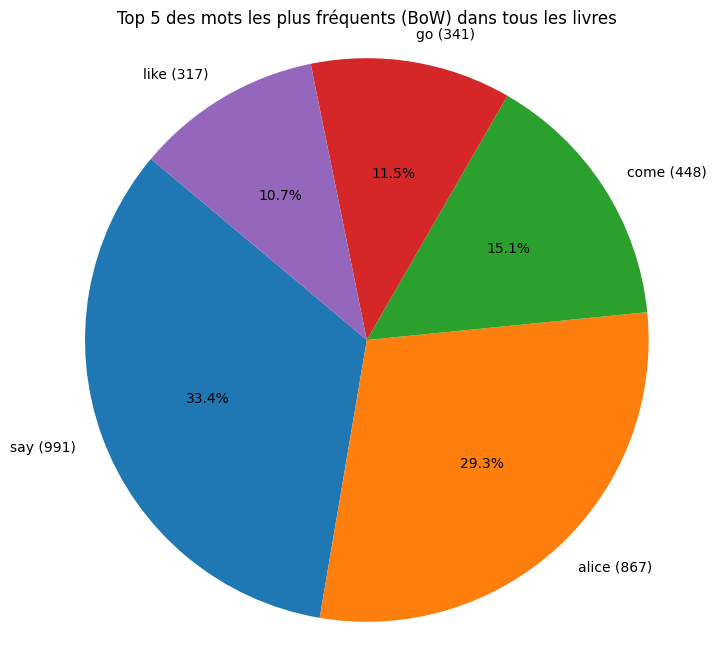

In [32]:
plt.figure(figsize=(8, 8))

labels = [f'{row.word} ({row.frequency})' for index, row in most_frequent_words.iterrows()]
plt.pie(most_frequent_words['frequency'], labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Top 5 des mots les plus fréquents (BoW) dans tous les livres')
plt.axis('equal')  # Un rapport d'aspect égal garantit que le camembert est dessiné comme un cercle.
plt.show()

#### 5. Analysez les sorties : Ces mots sont-ils informatifs ? Sont-ils perspicaces ou attendus ?

D'après la sortie Bag-of-Words (BoW) pour les mots les plus fréquents, nous trouvons souvent des mots courants comme "dit", "comme", "petit", "serait", "un", "aller", etc., à côté des noms de personnages ou des thèmes très centraux comme "alice", "roi", "reine", "temps", "porte".

**Sont-ils informatifs ?**

*   **Mots courants (par exemple, "dit", "comme", "serait") :** Ceux-ci ne sont généralement **pas très informatifs** en termes de contenu ou de thèmes uniques des livres. Ce sont des mots fonctionnels qui apparaissent fréquemment dans la prose narrative. Bien qu'ils indiquent un style conversationnel ou descriptif, ils ne nous disent pas grand-chose sur *l'objet* de l'histoire.

*   **Mots clés d'entité/de thème (par exemple, "alice", "roi", "reine") :** Ceux-ci sont **hautement informatifs** car ils se rapportent directement aux personnages principaux, aux décors ou aux éléments cruciaux des histoires de Lewis Carroll. Leur fréquence élevée est attendue compte tenu du sujet des livres.

**Sont-ils perspicaces ou attendus ?**

*   La présence de mots comme "Alice" est **attendue** compte tenu des titres des livres. De même, "roi" et "reine" sont attendus dans un cadre fantastique comme le Pays des Merveilles ou le Monde de l'Autre Côté du Miroir.

*   La fréquence élevée des verbes de parole courants (comme "dit") ou des adjectifs/quantificateurs génériques ("petit", "un") est également **attendue** dans tout texte écrit, en particulier la fiction narrative. Ils font partie de la structure du langage naturel.

**Analyse globale :**

La méthode BoW, en se contentant de compter les occurrences de mots, met en évidence à la fois des mots thématiques réellement importants (comme les noms de personnages) et des mots structurels très fréquents (comme les verbes, les adverbes) qui ne portent peut-être pas beaucoup de sens spécifique sur le *sujet* du document. C'est une limitation connue des simples comptages de fréquence. Les mots qui sont fréquents dans tous les documents (même après suppression des mots vides) ont tendance à dominer, ce qui les fait paraître importants, alors qu'en fait, ils peuvent être moins uniques ou moins différenciants. Cette observation prépare le terrain à la raison pour laquelle le TF-IDF est souvent utilisé, car il tente de sous-pondérer les mots qui sont courants dans tout le corpus et de sur-pondérer les mots qui sont distinctifs d'un document particulier.

### Résolution du problème de fréquence avec TF-IDF

Lorsque nous créons un BoW à partir d'un texte, tous les mots sont considérés comme également importants. Comme "Alice" ou "dire" dans un livre fantastique sur Alice. Nous nous attendions à ce que ces mots soient répétés dans tout le livre, ce qui les rendait peu informatifs pour nous.

La solution à ce problème serait de considérer la fréquence par rapport au corpus. Dans ce cas, si un mot dans un document n'apparaît pas beaucoup dans les autres documents, il est probablement significatif et devrait être considéré comme plus important. Et de la même manière dans le sens inverse : un mot qui est beaucoup répété dans tous les documents sera considéré comme moins important.

C'est la situation idéale pour utiliser le TF-IDF (Term Frequency-Inverse Document Frequency)

#### 1. Créez un autre BoW, en utilisant maintenant TF-IDF comme vectoriseur.

indice : Vous devez passer `min_df=1`, `max_df=2` comme arguments de `TfidfVectorizer()`, car nous utilisons un petit ensemble de données.

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Rejoindre les tokens lemmatisés en chaînes de caractères pour TfidfVectorizer
# (lemmatized_docs créé précédemment peut être réutilisé)

# Créer un TfidfVectorizer
# min_df=1 : Un mot doit apparaître dans au moins 1 document pour être pris en compte.
# max_df=2 : Un mot doit apparaître dans au plus 2 documents (sur 3) pour être pris en compte.
# Cela aide à filtrer les mots qui sont trop courants dans tous les documents d'un petit corpus.
tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=2)

tfidf_matrix = tfidf_vectorizer.fit_transform(lemmatized_docs)

# Obtenir les noms des caractéristiques (mots)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print("\n--- Matrice TF-IDF (format creux) ---")
print(tfidf_matrix)

print("\n--- Forme de la matrice TF-IDF (documents x mots_uniques) ---")
print(tfidf_matrix.shape)


--- Matrice TF-IDF (format creux) ---
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6336 stored elements and shape (3, 5389)>
  Coords	Values
  (0, 149)	0.8309481526976984
  (0, 5308)	0.006247730471411265
  (0, 2718)	0.0020825768238037553
  (0, 748)	0.0020825768238037553
  (0, 2966)	0.0020825768238037553
  (0, 1959)	0.0020825768238037553
  (0, 806)	0.04998184377129012
  (0, 3768)	0.14787026569662998
  (0, 3591)	0.03286005904369555
  (0, 4647)	0.002738338253641296
  (0, 766)	0.010953353014565183
  (0, 3769)	0.014578037766626287
  (0, 519)	0.04929008856554333
  (0, 761)	0.07941180935559759
  (0, 5133)	0.004165153647607511
  (0, 3507)	0.03748638282846759
  (0, 3432)	0.018743191414233796
  (0, 5141)	0.004165153647607511
  (0, 2835)	0.033321229180860085
  (0, 4644)	0.041651536476075106
  (0, 5142)	0.004165153647607511
  (0, 1135)	0.03286005904369555
  (0, 2998)	0.11870687895681405
  (0, 4901)	0.16977697172576034
  (0, 2774)	0.04107507380461944
  :	:
  (2, 812)	0.00165294963

#### 2. Créez à nouveau les diagrammes circulaires avec les 5 mots les plus pertinents de chaque document.

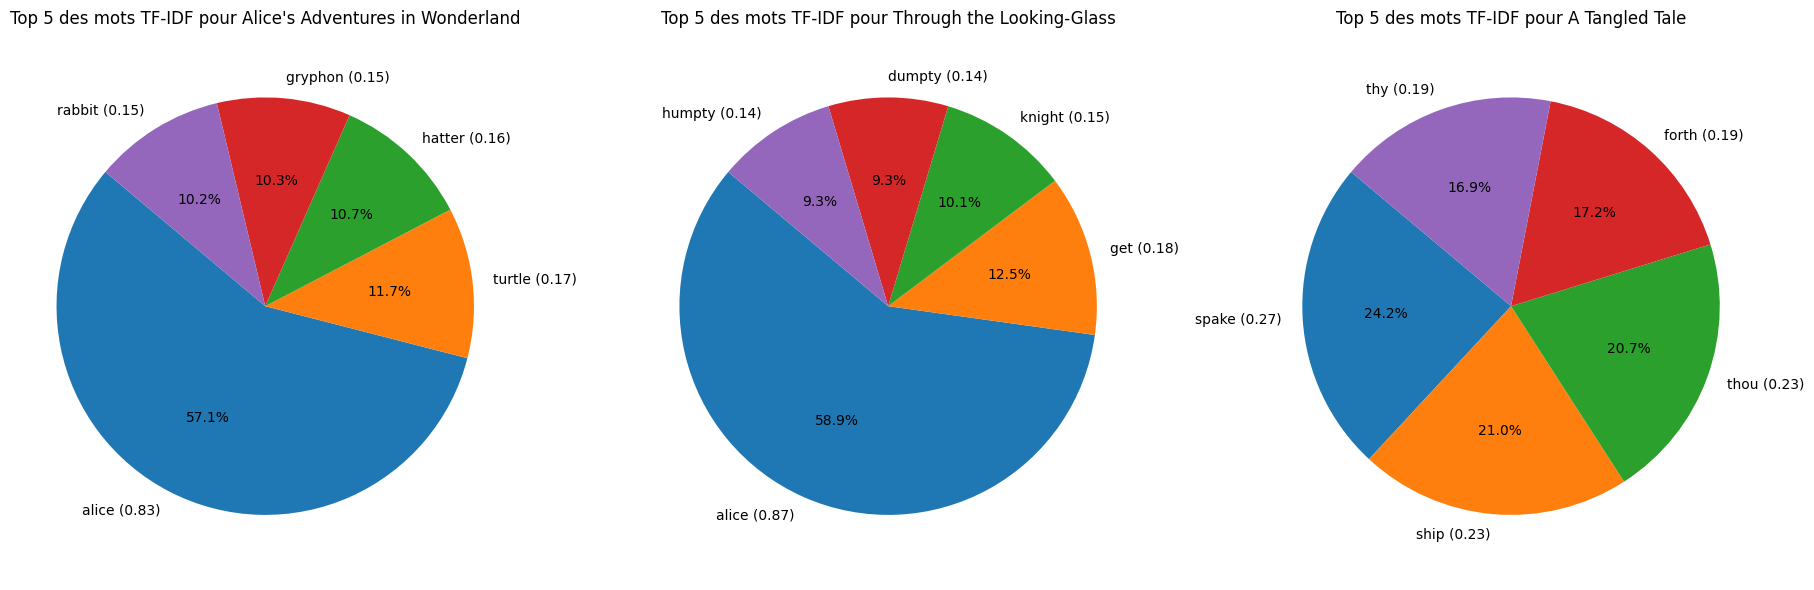


--- Les 5 premiers mots TF-IDF pour chaque livre ---

Livre : Alice's Adventures in Wonderland
         word  tfidf_score
149     alice     0.830948
4901   turtle     0.169777
2211   hatter     0.156085
2133  gryphon     0.150609
3768   rabbit     0.147870

Livre : Through the Looking-Glass
        word  tfidf_score
149    alice     0.868910
2015     get     0.183808
2631  knight     0.148917
1486  dumpty     0.136711
2363  humpty     0.136711

Livre : A Tangled Tale
       word  tfidf_score
4386  spake     0.267778
4215   ship     0.232565
4722   thou     0.228794
1908  forth     0.190089
4751    thy     0.187310


In [34]:
plt.figure(figsize=(18, 6))

for i, doc_title in enumerate(book_titles):
    # Obtenir les scores TF-IDF pour le document actuel
    doc_tfidf_scores = tfidf_matrix[i].toarray().flatten()

    # Créer un DataFrame pour un tri plus facile
    tfidf_df = pd.DataFrame({'word': tfidf_feature_names, 'tfidf_score': doc_tfidf_scores})

    # Obtenir les 5 premiers mots par score TF-IDF pour ce document
    top_5_tfidf = tfidf_df.sort_values(by='tfidf_score', ascending=False).head(5)

    plt.subplot(1, 3, i + 1) # 1 ligne, 3 colonnes

    labels = [f'{row.word} ({row.tfidf_score:.2f})' for index, row in top_5_tfidf.iterrows()]
    plt.pie(top_5_tfidf['tfidf_score'], labels=labels, autopct='%1.1f%%', startangle=140)
    plt.title(f'Top 5 des mots TF-IDF pour {doc_title}')
    plt.axis('equal') # Un rapport d'aspect égal garantit que le camembert est dessiné comme un cercle.

plt.tight_layout()
plt.show()

print("\n--- Les 5 premiers mots TF-IDF pour chaque livre ---")
for i, doc_title in enumerate(book_titles):
    doc_tfidf_scores = tfidf_matrix[i].toarray().flatten()
    tfidf_df = pd.DataFrame({'word': tfidf_feature_names, 'tfidf_score': doc_tfidf_scores})
    top_5_tfidf = tfidf_df.sort_values(by='tfidf_score', ascending=False).head(5)
    print(f"\nLivre : {doc_title}")
    print(top_5_tfidf)